# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [462]:
# Import warnings
import warnings
warnings.filterwarnings("ignore")


In [463]:
# Import the libraries you will be using for analysis
#Installing required versions before importing
!pip install pandas==2.2.2 numpy==1.26.4 matplotlib==3.10.0 seaborn==0.13.2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [464]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [465]:
# Try loading one file
file_path_first_parquet = r"D:\IIITBCourseContents\LiveClassPractice\EDA_Course_C2\EDA_NYC_TAXI_ASSIGNMENT\Starter-Files-EDA-NYC-Taxi\Starter Notebook - EDA NYC Taxi\trip_records\2023-1.parquet"
df_single_analysis = pd.read_parquet(file_path_first_parquet)
df_single_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [427]:

os.getcwd()

'D:\\IIITBCourseContents\\LiveClassPractice\\EDA_Course_C2\\EDA_NYC_TAXI_ASSIGNMENT\\Starter-Files-EDA-NYC-Taxi\\Starter Notebook - EDA NYC Taxi\\trip_records'

In [466]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files


# Select the folder having data files
os.chdir(r"D:\IIITBCourseContents\LiveClassPractice\EDA_Course_C2\EDA_NYC_TAXI_ASSIGNMENT\Starter-Files-EDA-NYC-Taxi\Starter Notebook - EDA NYC Taxi\trip_records")

# Create a list of all the twelve files to read
file_list = [f for f in os.listdir() if f.endswith('.parquet')]
target_size = 276000

print('File list -> ', file_list)

# initialise an empty dataframe
df = pd.DataFrame()

hourly_samples= []
# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        file_path = os.path.join(os.getcwd(), file_name)
        
        df_monthly = pd.read_parquet(file_path)
        df_monthly.columns = df_monthly.columns

        # helper columns
        df_monthly["pickup_date"] = df_monthly["tpep_pickup_datetime"].dt.date
        df_monthly["pickup_hour"] = df_monthly["tpep_pickup_datetime"].dt.hour

        for (_, _), df_group in df_monthly.groupby(["pickup_date", "pickup_hour"]):
            if df_group.empty:
                continue

            sampled_hour = df_group.sample(frac=0.05, random_state=42)
            hourly_samples.append(sampled_hour)

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")


df = pd.concat(hourly_samples, ignore_index=True)
current_size = len(df)


if current_size > target_size:
    frac_up = target_size / current_size

    final_df = df.sample(
        frac=frac_up,
        random_state=42
    ).reset_index(drop=True)
else:
    final_df = df.copy()

print("Final dataset size:", len(final_df))




File list ->  ['2023-1.parquet', '2023-10.parquet', '2023-11.parquet', '2023-12.parquet', '2023-2.parquet', '2023-3.parquet', '2023-4.parquet', '2023-5.parquet', '2023-6.parquet', '2023-7.parquet', '2023-8.parquet', '2023-9.parquet']
Final dataset size: 276000


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [467]:
# Store the df in csv/parquet
# df.to_parquet('')
final_df.to_csv('final_sampled.csv')
#df.shape
final_df.info()
 



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276000 entries, 0 to 275999
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               276000 non-null  int64         
 1   tpep_pickup_datetime   276000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  276000 non-null  datetime64[us]
 3   passenger_count        266602 non-null  float64       
 4   trip_distance          276000 non-null  float64       
 5   RatecodeID             266602 non-null  float64       
 6   store_and_fwd_flag     266602 non-null  object        
 7   PULocationID           276000 non-null  int64         
 8   DOLocationID           276000 non-null  int64         
 9   payment_type           276000 non-null  int64         
 10  fare_amount            276000 non-null  float64       
 11  extra                  276000 non-null  float64       
 12  mta_tax                276000 non-null  floa

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [468]:
# Load the new data file
df_new = pd.read_csv('final_sampled.csv')


In [469]:
# df.head()
df_new.head()


,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,0,2,2023-04-24 07:59:14,2023-04-24 08:10:54,2.0,1.68,1.0,N,143,238,...,0.5,1.00,0.00,1.0,17.80,2.5,NaN,2023-04-24,7,0.00
1,1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,N,186,170,...,0.5,0.00,0.00,1.0,14.00,2.5,0.0,2023-01-10,14,NaN
2,2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,N,132,151,...,0.5,10.00,6.55,1.0,89.30,0.0,NaN,2023-02-04,15,1.25
3,3,2,2023-03-28 10:29:26,2023-03-28 10:54:19,NaN,2.45,NaN,NaN,224,100,...,0.5,3.81,0.00,1.0,22.87,NaN,NaN,2023-03-28,10,NaN
4,4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,N,142,237,...,0.5,3.58,0.00,1.0,21.48,2.5,NaN,2023-09-05,17,0.00


In [470]:
# df.info()
df_new.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276000 entries, 0 to 275999
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             276000 non-null  int64  
 1   VendorID               276000 non-null  int64  
 2   tpep_pickup_datetime   276000 non-null  object 
 3   tpep_dropoff_datetime  276000 non-null  object 
 4   passenger_count        266602 non-null  float64
 5   trip_distance          276000 non-null  float64
 6   RatecodeID             266602 non-null  float64
 7   store_and_fwd_flag     266602 non-null  object 
 8   PULocationID           276000 non-null  int64  
 9   DOLocationID           276000 non-null  int64  
 10  payment_type           276000 non-null  int64  
 11  fare_amount            276000 non-null  float64
 12  extra                  276000 non-null  float64
 13  mta_tax                276000 non-null  float64
 14  tip_amount             276000 non-nu

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [471]:
# Fix the index and drop any columns that are not needed
df_new.reset_index(drop=True, inplace=True)
df_new.drop(columns=["Unnamed: 0","pickup_date", "pickup_hour"], errors="ignore",inplace=True)


df_new.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'Airport_fee'],
      dtype='object')

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [472]:
# Combine the two airport fee columns
#Max of both
cols = df_new.columns
df_new['airport_fee_combined'] = df_new[['airport_fee', 'Airport_fee']].max(axis=1)
df_new = df_new.drop(['airport_fee', 'Airport_fee'], axis=1)

df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276000 entries, 0 to 275999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               276000 non-null  int64  
 1   tpep_pickup_datetime   276000 non-null  object 
 2   tpep_dropoff_datetime  276000 non-null  object 
 3   passenger_count        266602 non-null  float64
 4   trip_distance          276000 non-null  float64
 5   RatecodeID             266602 non-null  float64
 6   store_and_fwd_flag     266602 non-null  object 
 7   PULocationID           276000 non-null  int64  
 8   DOLocationID           276000 non-null  int64  
 9   payment_type           276000 non-null  int64  
 10  fare_amount            276000 non-null  float64
 11  extra                  276000 non-null  float64
 12  mta_tax                276000 non-null  float64
 13  tip_amount             276000 non-null  float64
 14  tolls_amount           276000 non-nu

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [473]:
# check where values of fare amount are negative
df_new[df_new['fare_amount'] < 0]



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee_combined


Did you notice something different in the `RatecodeID` column for above records?

In [474]:
# Analyse RatecodeID for the negative fare amounts
neg_fare_amounts_df=df_new[df_new['fare_amount'] < 0]
neg_fare_amounts_df['RatecodeID'].value_counts(dropna = False)


Series([], Name: count, dtype: int64)

In [436]:
# Find which columns have negative values
num_cols = df_new.select_dtypes(include='number')

cols_with_negatives = [
    col for col in num_cols.columns
    if (num_cols[col] < 0).any()
]
cols_with_negatives

#rows_with_any_negative = df_new[(num_cols < 0).any(axis=1)]
#print(rows_with_any_negative)
#print('No of rows where atleast one value is negative:',rows_with_any_negative.shape)

['mta_tax',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee_combined']

In [475]:
# fix these negative values
#mta_tax can never be negative its a bug in data hence updating it to na
df_new.loc[df_new['mta_tax'] < 0, 'mta_tax'] = pd.NA

#improvement_surcharge can never be negative as it represents some kind of tax
df_new.loc[df_new['improvement_surcharge'] < 0, 'improvement_surcharge'] = pd.NA

#total_amount negative  can represent refund to be paid back to rider, will flag such rides by refund

df_new['rider_refund'] = df_new["total_amount"] < 0



#congestion surcharge can nver be negative as it represents tax
df_new.loc[df_new['congestion_surcharge'] < 0, 'congestion_surcharge'] = pd.NA

#airport_fee cannot be negative
df_new.loc[df_new['airport_fee_combined'] < 0, 'airport_fee_combined'] = pd.NA

df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276000 entries, 0 to 275999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               276000 non-null  int64  
 1   tpep_pickup_datetime   276000 non-null  object 
 2   tpep_dropoff_datetime  276000 non-null  object 
 3   passenger_count        266602 non-null  float64
 4   trip_distance          276000 non-null  float64
 5   RatecodeID             266602 non-null  float64
 6   store_and_fwd_flag     266602 non-null  object 
 7   PULocationID           276000 non-null  int64  
 8   DOLocationID           276000 non-null  int64  
 9   payment_type           276000 non-null  int64  
 10  fare_amount            276000 non-null  float64
 11  extra                  276000 non-null  float64
 12  mta_tax                275986 non-null  float64
 13  tip_amount             276000 non-null  float64
 14  tolls_amount           276000 non-nu

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [476]:
# Find the proportion of missing values in each column
missing_summary = pd.DataFrame({
    "missing_count": df_new.isna().sum(),
    "missing_percentage": df_new.isna().mean() * 100
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0] \
                    .sort_values("missing_percentage", ascending=False)

missing_summary


,missing_count,missing_percentage
congestion_surcharge,9412,3.410145
airport_fee_combined,9400,3.405797
passenger_count,9398,3.405072
RatecodeID,9398,3.405072
store_and_fwd_flag,9398,3.405072
improvement_surcharge,15,0.005435
mta_tax,14,0.005072


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [477]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'

null_passenger_rows = df_new[df_new["passenger_count"].isna()]
null_rows

#checking mean and median number of passenger_count
print(df_new['passenger_count'].mean())
print(df_new['passenger_count'].median())
print(df_new['passenger_count'].mode())

#Since median is 1 will impute passenger count with 1

df_new["passenger_count"].fillna(df_new["passenger_count"].mode()[0],inplace=True)

1.3692770496845486
1.0
0    1.0
Name: passenger_count, dtype: float64


Did you find zeroes in passenger_count? Handle these.

In [478]:
#checking for zero passenger count

df_new[(df_new['passenger_count'] == 0) & df_new['fare_amount'] > 0]

#Here we have 4298 rows where passenger_count is 0 and fare_amount > 0, which is a dataquality issue ---
#Proposal : Change passenger_count to 1 (as 1 being mode (most occuring) for records where fare_amount > 0

df_new.loc[(df_new["passenger_count"] == 0) & (df_new["fare_amount"] > 0),"passenger_count"] = 1

#Drop records where passenger count ==0 and fareamount ==0 as these are meaning less they dont add any value

mask_drop = (df_new["passenger_count"] == 0) & (df_new["fare_amount"] == 0)
df_new = df_new.loc[~mask_drop].reset_index(drop=True)




**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [479]:
# Fix missing values in 'RatecodeID'
missing_rateCodeId = df_new[df_new['RatecodeID'].isna()]
missing_rateCodeId

#As ratecodeid is categorical we will keep NaN values as some category with -1 as code
df_new["RatecodeID"] = df_new["RatecodeID"].fillna(-1).astype(int)


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [480]:
# handle null values in congestion_surcharge

mode_value = df_new["congestion_surcharge"].mode()[0]

#We go for most frequent value as imputation for congestion_surcharge as it keeps distribution intact
df_new["congestion_surcharge"].fillna(mode_value, inplace=True)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [481]:
# Handle any remaining missing values

#Checking missing values now

missing_summary = pd.DataFrame({
    "missing_count": df_new.isna().sum(),
    "missing_percentage": df_new.isna().mean() * 100
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0] \
                    .sort_values("missing_percentage", ascending=False)

#missing_summary


#for airport_fee we can safely impute with 0 as missing means ride has no airport
df_new['airport_fee_combined'].fillna(0,inplace=True)

#for store_and_fwd_flag impute with mode as it preserves distribution
most_store_and_fwd_flag_value = df_new['store_and_fwd_flag'].mode()[0]
#print('Mode is:',most_store_and_fwd_flag_value)
df_new['store_and_fwd_flag'].fillna(most_store_and_fwd_flag_value,inplace=True)

missing_summary

#Both improvement_surcharge and mta_tax represents fee and null usually means missing fee so we can assume it as 0
#Imputing with 0 
df_new['improvement_surcharge'].fillna(0,inplace=True)
df_new['mta_tax'].fillna(0,inplace=True)
missing_summary
print('Data is cleaned and null values are all taken care of')

Data is cleaned and null values are all taken care of


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [482]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

num_cols = df_new.select_dtypes(include='number').columns


def find_outliers(df,column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    #print('Lower bound for',column,' is ' ,lower, ' and upper bound ', upper)
    return df[(df[column] < lower) | (df[column] > upper)]

outlier_summary = {}

for col in num_cols:
    outlier_summary[col] = len(find_outliers(df_new, col))

outlier_df = (
    pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["outlier_count"])
    .sort_values("outlier_count", ascending=False)
)

outlier_df


    

,outlier_count
passenger_count,61896
payment_type,58953
trip_distance,36251
total_amount,31425
fare_amount,28510
RatecodeID,24339
airport_fee_combined,23427
tolls_amount,22258
tip_amount,21048
congestion_surcharge,20482


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [484]:
# remove passenger_count > 6
df_new = df_new[df_new['passenger_count'] <= 6]

In [485]:
# Continue with outlier handling

df_new.info()
df_new = df_new[~((df_new['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]
df_new = df_new[~((df_new['trip_distance'] == 0) & (df_new['fare_amount'] == 0) & (df_new['PULocationID'] != df_new['DOLocationID']))]
df_new = df_new[df_new['trip_distance'] <= 250]

df_new = df_new[df_new['payment_type'] != 0]

<class 'pandas.core.frame.DataFrame'>
Index: 275995 entries, 0 to 275995
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               275995 non-null  int64  
 1   tpep_pickup_datetime   275995 non-null  object 
 2   tpep_dropoff_datetime  275995 non-null  object 
 3   passenger_count        275995 non-null  float64
 4   trip_distance          275995 non-null  float64
 5   RatecodeID             275995 non-null  int32  
 6   store_and_fwd_flag     275995 non-null  object 
 7   PULocationID           275995 non-null  int64  
 8   DOLocationID           275995 non-null  int64  
 9   payment_type           275995 non-null  int64  
 10  fare_amount            275995 non-null  float64
 11  extra                  275995 non-null  float64
 12  mta_tax                275995 non-null  float64
 13  tip_amount             275995 non-null  float64
 14  tolls_amount           275995 non-null  f

In [486]:
# Do any columns need standardising?
#Columns that represent numerical value and distance can be standardised by z-score method into seperate columns...
amount_cols = [
    "fare_amount",
    "total_amount",
    "trip_distance",
    "tip_amount",
    "tolls_amount",
    "extra",
    "congestion_surcharge",
    "airport_fee_combined"
]
for col in amount_cols:
    mean = df_new[col].mean()
    std = df_new[col].std()

    df_new[col + "_std"] = (df_new[col] - mean) / std


df_new.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,airport_fee_combined,rider_refund,fare_amount_std,total_amount_std,trip_distance_std,tip_amount_std,tolls_amount_std,extra_std,congestion_surcharge_std,airport_fee_combined_std
0,2,2023-04-24 07:59:14,2023-04-24 08:10:54,2.0,1.68,1,N,143,238,1,...,0.00,False,-0.376729,-0.481080,-0.387731,-0.622838,-0.272245,-0.892141,0.288404,-0.307429
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1,N,186,170,2,...,0.00,False,-0.528362,-0.646046,-0.559165,-0.864388,-0.272245,-0.892141,0.288404,-0.307429
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2,N,132,151,1,...,1.25,False,2.720920,2.622882,3.878342,1.551118,2.742690,-0.892141,-3.467351,2.381522
4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1,N,142,237,1,...,0.00,False,-0.452546,-0.321324,-0.374544,0.000363,-0.272245,0.468713,0.288404,-0.307429
5,2,2023-11-15 08:41:24,2023-11-15 09:01:54,1.0,2.24,1,N,236,161,1,...,0.00,False,-0.073463,-0.038277,-0.264650,0.488295,-0.272245,-0.892141,0.288404,-0.307429


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [447]:
df_new.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee_combined',
 'rider_refund',
 'fare_amount_std',
 'total_amount_std',
 'trip_distance_std',
 'tip_amount_std',
 'tolls_amount_std',
 'extra_std',
 'congestion_surcharge_std',
 'airport_fee_combined_std']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

In [ ]:
#vendor id : Categorical
#tpep_pickup_datetime: Datetime
#tpep_dropoff_datetime: Datetime
#passenger_count: Numerical (Discrete)
#trip_distance: Numerical (Continuos)
#RateCodeID : Categorical
# PULocationID: Categorical
# DOLocationID	Categorical	
# payment_type	Categorical	
# pickup_hour	Categorical / Ordinal	
# trip_duration	Numerical (Continuous)	

# Monetary variables

# fare_amount	Numerical (Continuous)	
# extra	Numerical (Continuous)	
# mta_tax	Numerical (Continuous)	
# tip_amount	Numerical (Continuous)	
# tolls_amount	Numerical (Continuous)	
# improvement_surcharge	Numerical (Continuous)	
# congestion_surcharge	Numerical (Continuous)	
# airport_fee	Numerical (Continuous)	
# total_amount	Numerical (Continuous)	

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

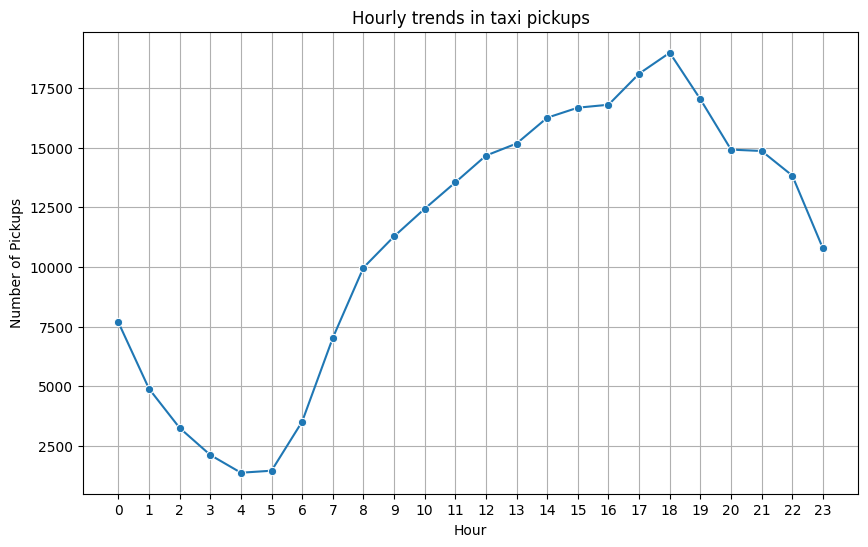

In [487]:
# Find and show the hourly trends in taxi pickups


df_new["tpep_pickup_datetime"] = pd.to_datetime(df_new["tpep_pickup_datetime"])
df_new["tpep_dropoff_datetime"] = pd.to_datetime(df_new["tpep_dropoff_datetime"])

df_new['pickup_hour'] = df_new['tpep_pickup_datetime'].dt.hour
hourly_trend = df_new.groupby('pickup_hour').size().reset_index(name='pickup')


plt.figure(figsize=(10, 6))
sns.lineplot(data=hourly_trend, x='pickup_hour', y='pickup', marker='o')


plt.title('Hourly trends in taxi pickups')
plt.xlabel('Hour')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 24))
plt.grid(True)



plt.show()


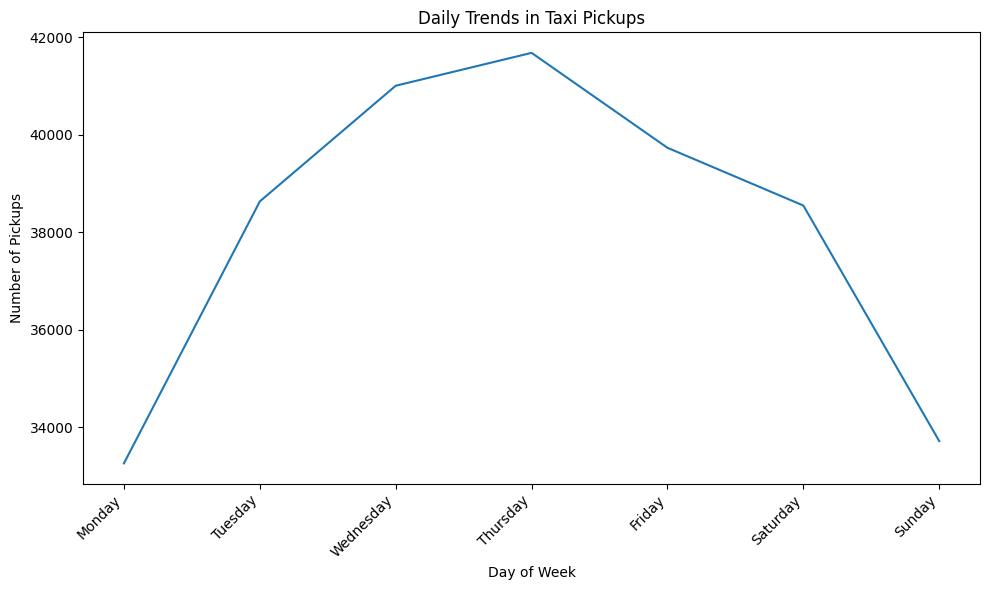

In [488]:
# Find and show the daily trends in taxi pickups (days of the week)
df_new['pickup_day'] = df_new['tpep_pickup_datetime'].dt.day_name()

daily_pickups = df_new.groupby('pickup_day')['tpep_pickup_datetime'].count()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_pickups = daily_pickups.reindex(days_order)

plt.figure(figsize=(10, 6))
sns.lineplot(x=daily_pickups.index, y=daily_pickups.values)  # Using Seaborn for better aesthetics

plt.xlabel('Day of Week')
plt.ylabel('Number of Pickups')
plt.title('Daily Trends in Taxi Pickups')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


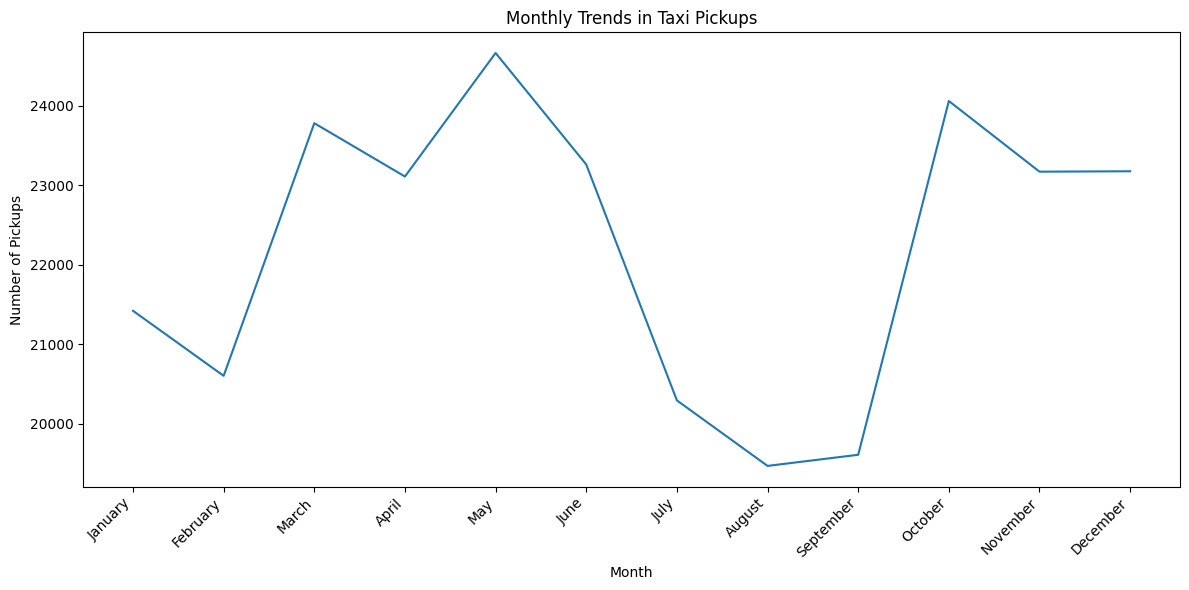

In [489]:
# Show the monthly trends in pickups
df_new['pickup_month'] = df_new['tpep_pickup_datetime'].dt.month_name()
monthly_pickups = df_new.groupby('pickup_month')['tpep_pickup_datetime'].count()
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_pickups = monthly_pickups.reindex(months_order)

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_pickups.index, y=monthly_pickups.values)
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.title('Monthly Trends in Taxi Pickups')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [490]:
# Analyse the above parameters
cols_to_check = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']
summary = pd.DataFrame(columns=cols_to_check)
summary.loc['Zero Count'] = [ (df_new[col] == 0).sum() for col in cols_to_check ]
summary.loc['Negative Count'] = [ (df_new[col] < 0).sum() for col in cols_to_check ]
summary.round(2)

,fare_amount,tip_amount,total_amount,trip_distance
Zero Count,80,59913,33,3310
Negative Count,0,0,14,0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [491]:
# Create a df with non zero entries for the selected parameters.
filtered_df = df_new.copy()
filtered_df = filtered_df[
    (filtered_df['fare_amount'] != 0) &
    (filtered_df['total_amount'] > 0) &
    (filtered_df['tip_amount'] !=0 ) &
    (filtered_df['trip_distance'] != 0)
]
print(f"Original shape: {df_new.shape}")
print(f"Filtered shape: {filtered_df.shape}")


Original shape: (266585, 31)
Filtered shape: (205487, 31)


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

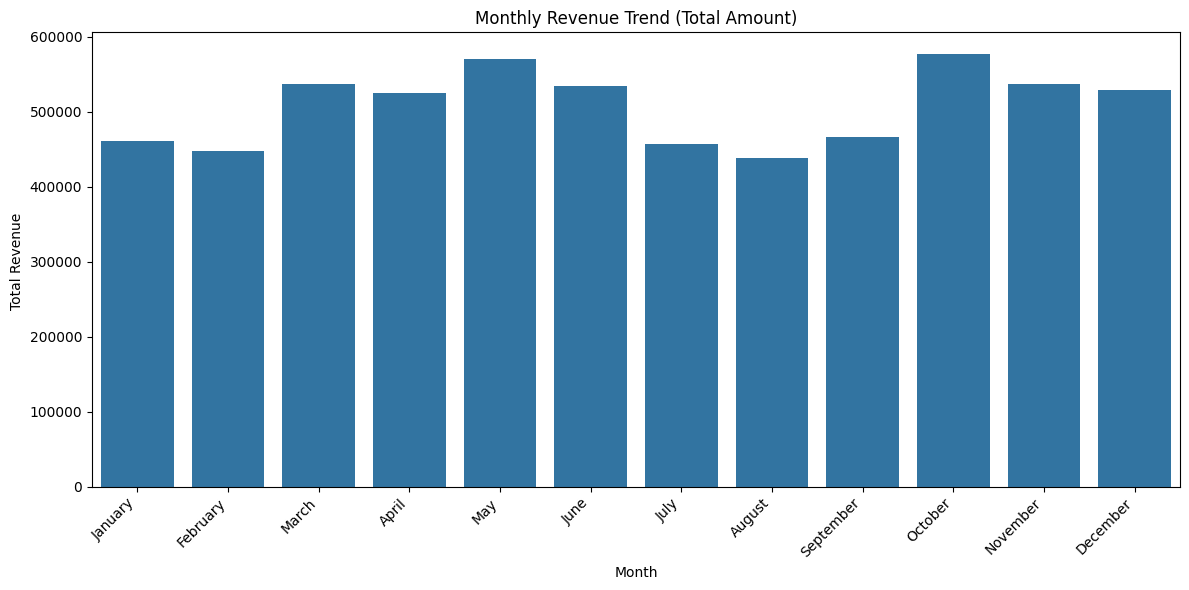

In [492]:
# Group data by month and analyse monthly revenue
if 'pickup_month' not in filtered_df.columns:
    filtered_df['pickup_month'] = filtered_df['tpep_pickup_datetime'].dt.month_name()

monthly_revenue = filtered_df.groupby('pickup_month')['total_amount'].sum()
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
monthly_revenue = monthly_revenue.reindex(months_order)

plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values)
plt.title('Monthly Revenue Trend (Total Amount)')
plt.xlabel('Month')
plt.ylabel('Total Revenue ')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

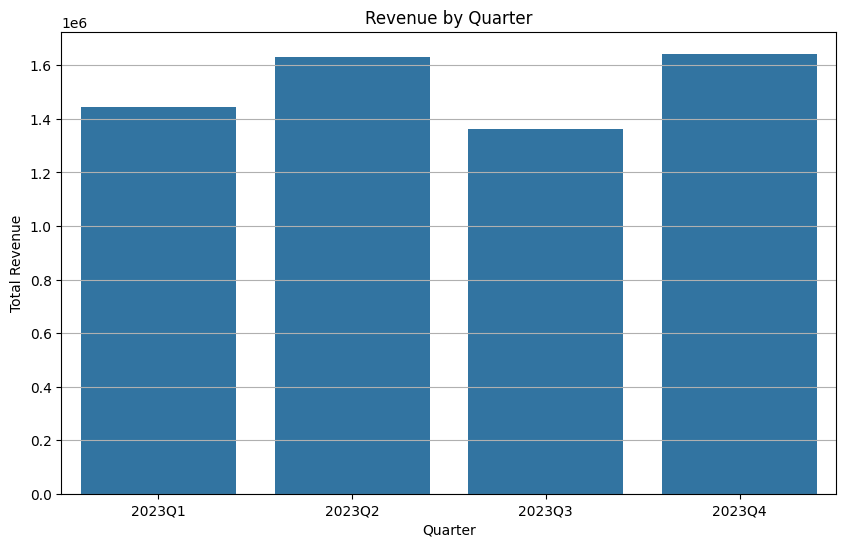

In [493]:
# Calculate proportion of each quarter

filtered_df['quarter_of_pickup'] = filtered_df['tpep_pickup_datetime'].dt.to_period('Q')
quarterly_revenue = (filtered_df.groupby('quarter_of_pickup')['total_amount'].sum().reset_index())
quarterly_proportion.round(2)

quarterly_revenue['quarter'] = quarterly_revenue['quarter_of_pickup'].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(data=quarterly_revenue,x="quarter",y="total_amount")

plt.title("Revenue by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Total Revenue")
plt.grid(axis="y")

plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

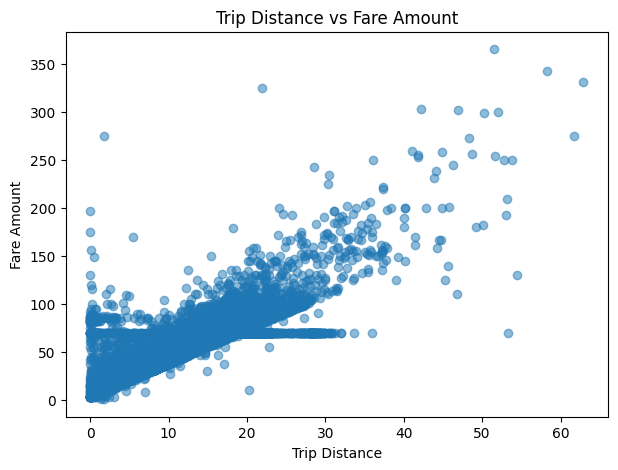

Correlation between trip distance and fare amount (excluding zero distance trips): 0.90


In [494]:
#Show how trip fare is affected by distance


df_corr = filtered_df[(filtered_df["trip_distance"] > 0) & (filtered_df["fare_amount"] > 0)].copy()

plt.figure(figsize=(7, 5))
plt.scatter(
    df_corr["trip_distance"],
    df_corr["fare_amount"],
    alpha=0.5
)
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.title("Trip Distance vs Fare Amount")
plt.show()

correlation = df_new['trip_distance'].corr(df_new['fare_amount'])
print(f"Correlation between trip distance and fare amount (excluding zero distance trips): {correlation:.2f}")



**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

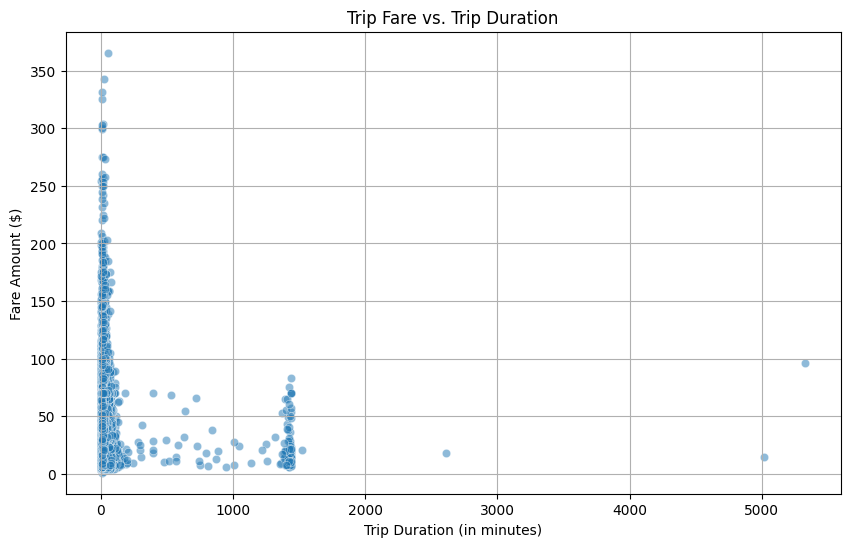

Correlation between trip duration and fare amount: 0.004470954566379133


In [495]:
# Show relationship between fare and trip duration

date_cols = ['tpep_dropoff_datetime','tpep_pickup_datetime']
for col in date_cols:
     filtered_df[col] = pd.to_datetime(df[col], errors="coerce")
filtered_df['trip_duration'] = (filtered_df['tpep_dropoff_datetime'] - filtered_df['tpep_pickup_datetime']).dt.total_seconds()/60

plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_duration', y='fare_amount', data=filtered_df, alpha=0.5)  # Added alpha for better visibility
plt.title('Trip Fare vs. Trip Duration')
plt.xlabel('Trip Duration (in minutes)')
plt.ylabel('Fare Amount ($)')
plt.grid(True)
plt.show()

correlation = filtered_df['trip_duration'].corr(filtered_df['fare_amount'])
print(f"Correlation between trip duration and fare amount: {correlation}")



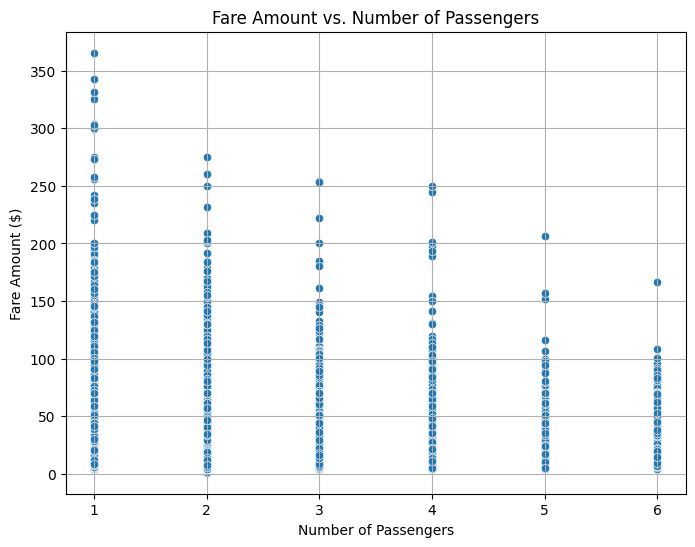

Correlation between passenger count and fare amount: 0.04


In [360]:
# Show relationship between fare and number of passengers
plt.figure(figsize=(8, 6))
sns.scatterplot(x='passenger_count', y='fare_amount', data=filtered_df)
plt.title('Fare Amount vs. Number of Passengers')
plt.xlabel('Number of Passengers')
plt.ylabel('Fare Amount ($)')
plt.grid(True)
plt.show()

correlation = filtered_df['passenger_count'].corr(filtered_df['fare_amount'])
print(f"Correlation between passenger count and fare amount: {correlation:.2f}")



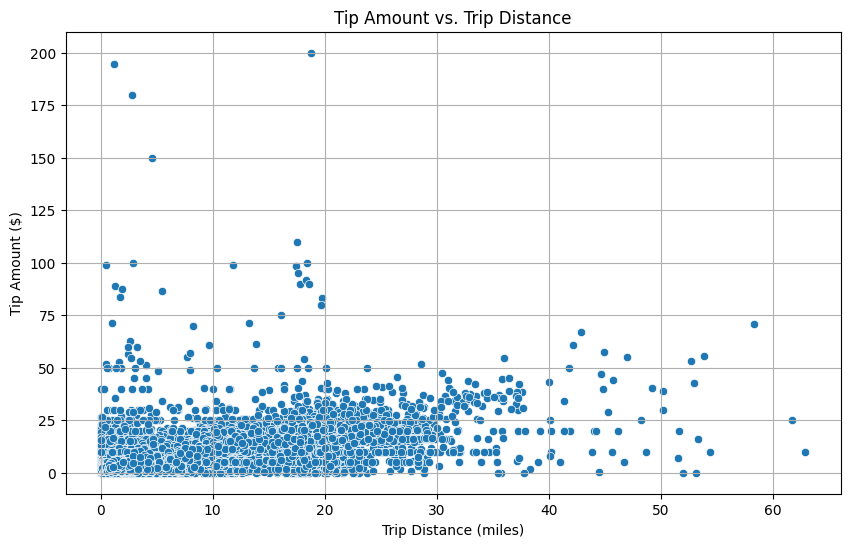

Correlation between trip distance and tip amount: 0.79


In [366]:
# Show relationship between tip and trip distance
plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_distance', y='tip_amount', data=filtered_df)  # Added alpha for better visibility
plt.title('Tip Amount vs. Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount ($)')
plt.grid(True)
plt.show()

correlation = filtered_df['trip_distance'].corr(filtered_df['tip_amount'])
print(f"Correlation between trip distance and tip amount: {correlation:.2f}")


**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

payment_type_label
Credit Card    217037
Cash            46245
Dispute          1972
No Charge        1331
Name: count, dtype: int64


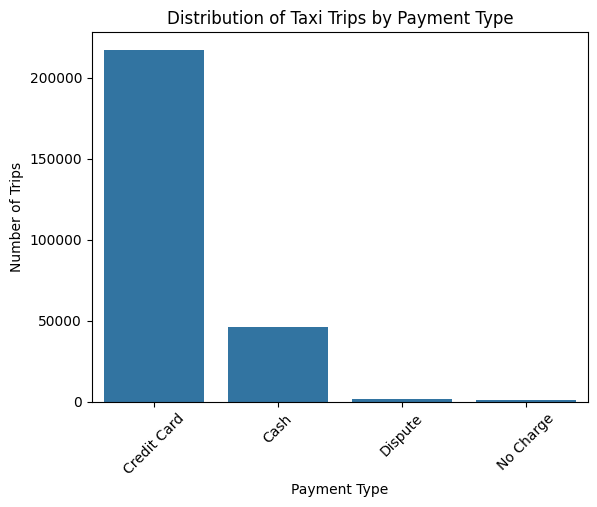

In [367]:
# Analyse the distribution of different payment types (payment_type).

payment_type_map = {
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided Trip"
}

df_new["payment_type_label"] = df_new["payment_type"].map(payment_type_map)


df_new["payment_type_label"].value_counts(dropna=False)
payment_counts = df_new["payment_type_label"].value_counts()
print(payment_counts)

sns.countplot(
    data=df_new,
    x="payment_type_label",
    order=payment_counts.index
)

plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")
plt.title("Distribution of Taxi Trips by Payment Type")
plt.xticks(rotation=45)
plt.show()


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [190]:
# !pip install geopandas
!pip install geopandas

   ---------------------------------------- 0.0/341.7 kB ? eta -:--:--
   ---------- ----------------------------- 92.2/341.7 kB 1.7 MB/s eta 0:00:01
   ----------------------- ---------------- 204.8/341.7 kB 2.1 MB/s eta 0:00:01
   ------------------------------------- -- 317.4/341.7 kB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 341.7/341.7 kB 1.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/22.9 MB 491.5 kB/s eta 0:00:47
   ---------------------------------------- 0.1/22.9 MB 535.8 kB/s eta 0:00:43
   ---------------------------------------- 0.2/22.9 MB 654.6 kB/s eta 0:00:35
   ---------------------------------------- 0.3/22.9 MB 923.9 kB/s eta 0:00:25
    --------------------------------------- 0.3/22.9 MB 1.1 MB/s eta 0:00:21
    ---

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [368]:
# import geopandas as gpd
import geopandas as gpd

TAXI_ZONE_FILE_PATH = r"D:\IIITBCourseContents\LiveClassPractice\EDA_Course_C2\EDA_NYC_TAXI_ASSIGNMENT\Starter-Files-EDA-NYC-Taxi\Datasets and Dictionary-NYC\Datasets and Dictionary\taxi_zones\taxi_zones.shp"
zones = gpd.read_file(TAXI_ZONE_FILE_PATH)

# read the .shp file using gpd
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

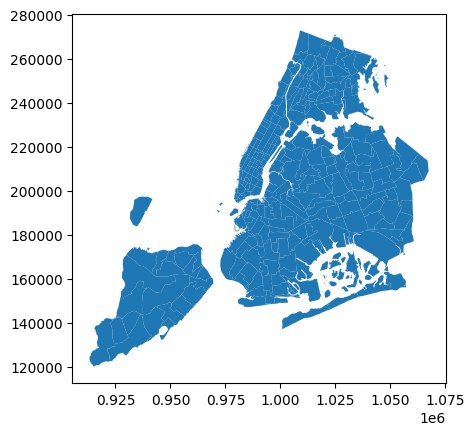

In [370]:
 print(zones.info())
 zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [371]:
# Merge zones and trip records using locationID and PULocationID

merged_df = pd.merge(df_new, zones, left_on='PULocationID', right_on='LocationID', how='left')

merged_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_day,pickup_month,payment_type_label,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2023-04-24 07:59:14,2023-04-24 08:10:54,2.0,1.68,1,N,143,238,1,...,Monday,April,Credit Card,143.0,0.054180,0.000151,Lincoln Square West,143.0,Manhattan,"POLYGON ((989338.1 223572.253, 989368.225 2235..."
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1,N,186,170,2,...,Tuesday,January,Cash,186.0,0.024696,0.000037,Penn Station/Madison Sq West,186.0,Manhattan,"POLYGON ((986752.603 210853.699, 986627.863 21..."
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2,N,132,151,1,...,Saturday,February,Credit Card,132.0,0.245479,0.002038,JFK Airport,132.0,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283..."
3,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1,N,142,237,1,...,Tuesday,September,Credit Card,142.0,0.038176,0.000076,Lincoln Square East,142.0,Manhattan,"POLYGON ((989380.305 218980.247, 989359.803 21..."
4,2,2023-11-15 08:41:24,2023-11-15 09:01:54,1.0,2.24,1,N,236,161,1,...,Wednesday,November,Credit Card,236.0,0.044252,0.000103,Upper East Side North,236.0,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [373]:
# Group data by location and calculate the number of trips
trip_counts = merged_df.groupby('PULocationID').size().reset_index(name='num_trips')
trip_counts


,PULocationID,num_trips
0,1,29
1,3,9
2,4,314
3,5,4
4,6,4
...,...,...
235,261,1447
236,262,3420
237,263,5092
238,264,2590


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [374]:
# Merge trip counts back to the zones GeoDataFrame

zones_with_trips = pd.merge(zones, trip_counts, left_on='LocationID', right_on='PULocationID', how='left')
zones_with_trips.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,num_trips
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,29.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN,NaN
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,9.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,314.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",5.0,4.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

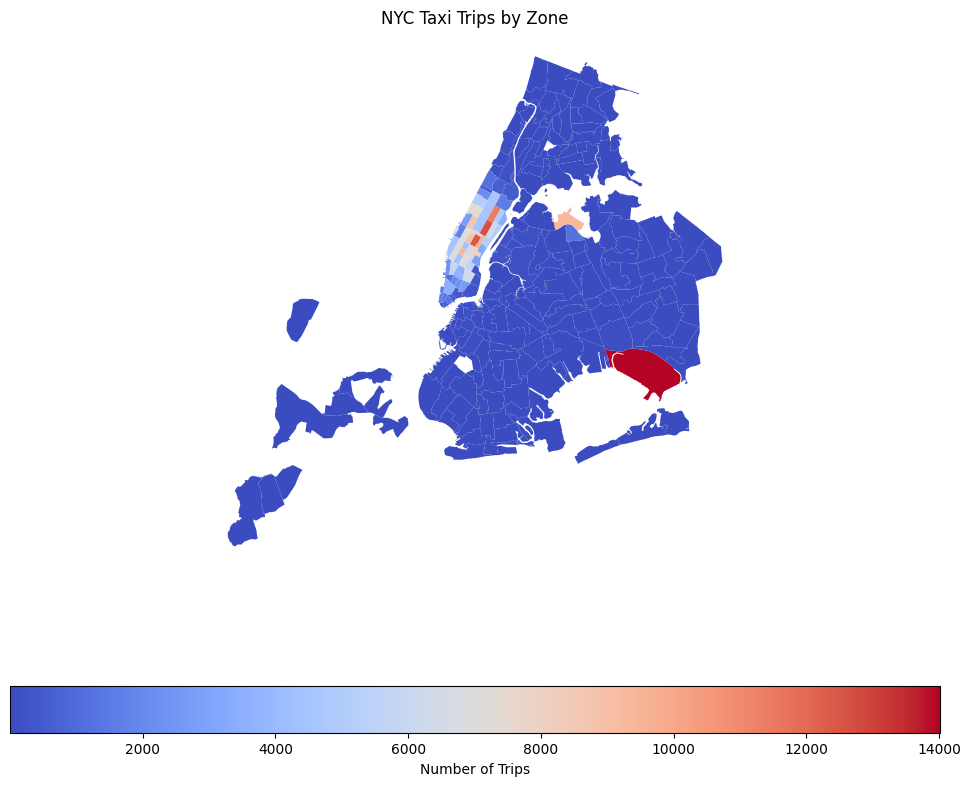

In [375]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
zones_with_trips.plot(
    column='num_trips',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': "Number of Trips",
        'orientation': "horizontal"
    },
    cmap='coolwarm'
)

ax.set_title("NYC Taxi Trips by Zone")
plt.axis('off')
plt.show()

# Plot the map and display it



In [376]:
# can you try displaying the zones DF sorted by the number of trips?
zones_with_trips_sorted = zones_with_trips.sort_values(by='num_trips', ascending=False)
zones_with_trips_sorted.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,num_trips
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",132.0,14016.0
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",237.0,12694.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",161.0,12416.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",236.0,11427.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",162.0,9571.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [377]:
# Find routes which have the slowest speeds at different times of the day

#df_new.info()
df_route = df_new[['PULocationID', 'DOLocationID', 'trip_distance', 'tpep_pickup_datetime', 'tpep_dropoff_datetime']].copy()
df_route['trp_time_hrs'] = (df_route['tpep_dropoff_datetime'] - df_route['tpep_pickup_datetime']).dt.total_seconds() / 3600
df_route = df_route[(df_route['trp_time_hrs'] > 0) & (df_route['trip_distance'] > 0)]
df_route['pickup_hour'] = df_route['tpep_pickup_datetime'].dt.hour
grouped = df_route.groupby(['PULocationID', 'DOLocationID', 'pickup_hour'])
speed_data = grouped.agg({
    'trip_distance': 'mean',
    'trp_time_hrs': 'mean'
}).reset_index()
speed_data['avg_speed_mph'] = speed_data['trip_distance'] / speed_data['trp_time_hrs']
slowest_routes = speed_data.sort_values(by='avg_speed_mph').head(10)
print(slowest_routes[['PULocationID', 'DOLocationID', 'pickup_hour', 'avg_speed_mph']])


       PULocationID  DOLocationID  pickup_hour  avg_speed_mph
42779           194           194           15       0.002741
60744           264           132           14       0.008469
28461           142           142            5       0.023770
32085           151            24            1       0.032131
16759           113           235           22       0.048105
42780           194           194           16       0.048913
31843           148           232           12       0.051573
4682             48           229            0       0.061705
22515           137            68           20       0.071780
6158             67           215           15       0.078091


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

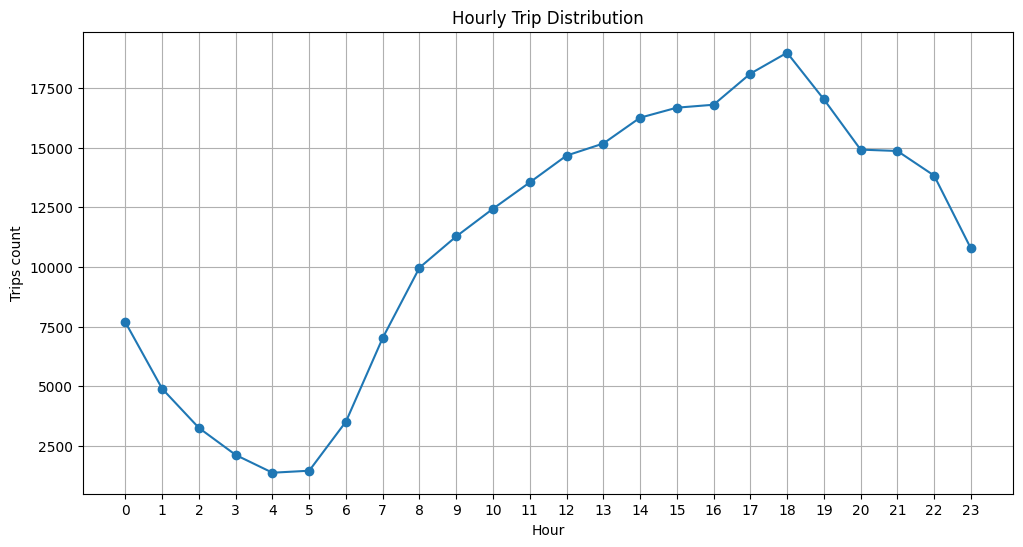

Busiest hour: 18
Number of trips during busiest hour: 18969


In [378]:
# Visualise the number of trips per hour and find the busiest hour
df_new['pickup_hour'] = df_new['tpep_pickup_datetime'].dt.hour
hourly_trips = df_new.groupby('pickup_hour')['tpep_pickup_datetime'].count().reset_index(name='trip_count')
busiest_hour = hourly_trips.loc[hourly_trips['trip_count'].idxmax()]

plt.figure(figsize=(12, 6))
plt.plot(hourly_trips['pickup_hour'], hourly_trips['trip_count'], marker='o')
plt.title('Hourly Trip Distribution')
plt.xlabel('Hour')
plt.ylabel('Trips count')
plt.xticks(range(24))
plt.grid(True)
plt.show()
print(f"Busiest hour: {busiest_hour['pickup_hour']}")
print(f"Number of trips during busiest hour: {busiest_hour['trip_count']}")


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [379]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05 * target_size / current_size

print(sample_fraction)
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
trip_counts = df['pickup_hour'].value_counts().sort_index()
top5_hours = trip_counts.sort_values(ascending=False).head(5)
scaled_top5 = (top5_hours / sample_fraction).astype(int)
top5_hours


0.007276945792026999


pickup_hour
18    133938
17    127867
19    119662
16    117512
15    117407
Name: count, dtype: int64

**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

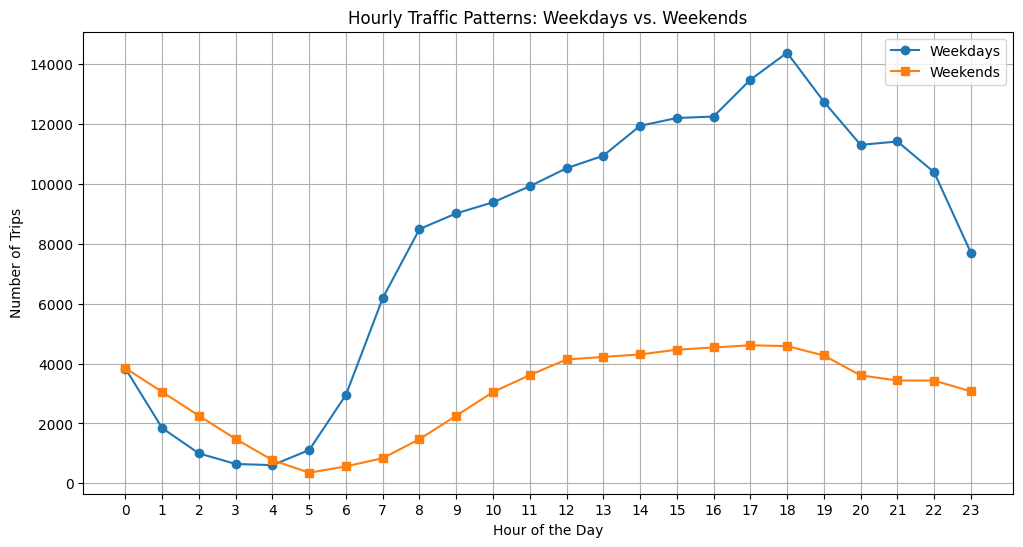

In [380]:
# Compare traffic trends for the week days and weekends

df_new['day_of_week'] = df_new['tpep_pickup_datetime'].dt.dayofweek  # Monday=0, Sunday=6
weekdays_df = df_new[df_new['day_of_week'] < 5]  # Monday to Friday
weekends_df = df_new[df_new['day_of_week'] >= 5]  # Saturday and Sunday
weekday_hourly_counts = weekdays_df.groupby(weekdays_df['tpep_pickup_datetime'].dt.hour)['tpep_pickup_datetime'].count()
weekend_hourly_counts = weekends_df.groupby(weekends_df['tpep_pickup_datetime'].dt.hour)['tpep_pickup_datetime'].count()

plt.figure(figsize=(12, 6))
plt.plot(weekday_hourly_counts.index, weekday_hourly_counts.values, label='Weekdays', marker='o')
plt.plot(weekend_hourly_counts.index, weekend_hourly_counts.values, label='Weekends', marker='s')
plt.title('Hourly Traffic Patterns: Weekdays vs. Weekends')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [382]:
# Find top 10 pickup and dropoff zones
# Count pickups by location ID
top_pu = df_new['PULocationID'].value_counts().head(10).reset_index()
top_pu.columns = ['LocationID', 'Pickup_Trips']

# Merge with zones to get zone names
top_pu = top_pu.merge(zones[['LocationID', 'zone']], on='LocationID', how='left')
print("Top 10 Pickup Zones:")
top_pu


Top 10 Pickup Zones:


,LocationID,Pickup_Trips,zone
0,132,14016,JFK Airport
1,237,12694,Upper East Side South
2,161,12416,Midtown Center
3,236,11427,Upper East Side North
4,162,9571,Midtown East
5,138,9359,LaGuardia Airport
6,186,9294,Penn Station/Madison Sq West
7,230,8902,Times Sq/Theatre District
8,142,8791,Lincoln Square East
9,170,7898,Murray Hill


In [383]:
#top 10 drop off zones

top_do = df_new['DOLocationID'].value_counts().head(10).reset_index()
top_do.columns = ['LocationID', 'Dropoff_Trips']

# Merge with zones to get zone names
top_do = top_do.merge(zones[['LocationID', 'zone']], on='LocationID', how='left')
print("Top 10 Dropoff Zones:")
top_do

Top 10 Dropoff Zones:


,LocationID,Dropoff_Trips,zone
0,236,11837,Upper East Side North
1,237,11132,Upper East Side South
2,161,10403,Midtown Center
3,230,8345,Times Sq/Theatre District
4,170,7803,Murray Hill
5,162,7642,Midtown East
6,142,7583,Lincoln Square East
7,239,7318,Upper West Side South
8,141,7063,Lenox Hill West
9,68,6695,East Chelsea


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [385]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pickup_counts = df['PULocationID'].value_counts().rename('pickup_count')
dropoff_counts = df['DOLocationID'].value_counts().rename('dropoff_count')

ratios = pd.concat([pickup_counts, dropoff_counts], axis=1).fillna(0)
ratios['pickup_dropoff_ratio'] = ratios['pickup_count'] / ratios['dropoff_count'].replace(0, np.nan)
ratios = ratios.reset_index().rename(columns={'index': 'LocationID'})
ratios = ratios.merge(zones[['LocationID', 'zone']], on='LocationID', how='left')
ratios = ratios.set_index('zone')
pickup_dropoff_ratios = ratios['pickup_dropoff_ratio']
top_pickup_dropoff_ratio = pickup_dropoff_ratios.sort_values(ascending=False).head(10)
bottom_pickup_dropoff_ratio = pickup_dropoff_ratios.sort_values().head(10)

top_pickup_dropoff_ratio

zone
East Elmhurst                   8.149225
JFK Airport                     4.263553
LaGuardia Airport               2.620624
Penn Station/Madison Sq West    1.556960
Greenwich Village South         1.376644
Central Park                    1.368748
West Village                    1.332370
Midtown East                    1.242286
Midtown Center                  1.187999
Garment District                1.186987
Name: pickup_dropoff_ratio, dtype: float64

In [239]:
bottom_pickup_dropoff_ratio

zone
Freshkills Park                        0.000000
Broad Channel                          0.000000
Oakwood                                0.000000
West Brighton                          0.032258
Newark Airport                         0.037953
Grymes Hill/Clifton                    0.040000
Breezy Point/Fort Tilden/Riis Beach    0.051282
Windsor Terrace                        0.053952
Mariners Harbor                        0.068966
Whitestone                             0.071038
Name: pickup_dropoff_ratio, dtype: float64

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [388]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

night_df = df_new[(df_new['tpep_pickup_datetime'].dt.hour >= 23) | (df_new['tpep_pickup_datetime'].dt.hour < 5)]
night_df = night_df.merge(
    zones[['LocationID', 'zone']].rename(columns={'zone': 'pickup_zone'}),
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)
night_df = night_df.merge(
    zones[['LocationID', 'zone']].rename(columns={'zone': 'dropoff_zone'}),
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
)
top_night_pickups = night_df.groupby('pickup_zone')['PULocationID'].count().sort_values(ascending=False).head(10)
top_night_dropoffs = night_df.groupby('dropoff_zone')['DOLocationID'].count().sort_values(ascending=False).head(10)
top_night_pickups

pickup_zone
East Village                    2210
JFK Airport                     1998
West Village                    1769
Clinton East                    1383
Lower East Side                 1355
Greenwich Village South         1318
Times Sq/Theatre District       1147
Penn Station/Madison Sq West     898
East Chelsea                     869
LaGuardia Airport                852
Name: PULocationID, dtype: int64

In [242]:
top_night_dropoffs

dropoff_zone
East Village                     1148
Clinton East                     1006
Murray Hill                       881
Gramercy                          867
Lenox Hill West                   803
East Chelsea                      796
West Village                      740
Yorkville West                    691
Lower East Side                   667
Sutton Place/Turtle Bay North     628
Name: dolocationid, dtype: int64

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [389]:
# Filter for night hours (11 PM to 5 AM)

df_new['pickup_hour'] = df_new['tpep_pickup_datetime'].dt.hour

nighttime_df = df_new[(df_new['pickup_hour'] >= 23) | (df_new['pickup_hour'] <= 5)]  # 11 PM - 5 AM
daytime_df = df_new[(df_new['pickup_hour'] >= 6) & (df_new['pickup_hour'] <= 22)]  # 6 AM - 10 PM

nighttime_revenue = nighttime_df['total_amount'].sum()
daytime_revenue = daytime_df['total_amount'].sum()

total_revenue = df_new['total_amount'].sum()

nighttime_revenue_share = (nighttime_revenue / total_revenue) * 100
daytime_revenue_share = (daytime_revenue / total_revenue) * 100

print(f"Nighttime Revenue Share: {nighttime_revenue_share:.2f}%")
print(f"Daytime Revenue Share: {daytime_revenue_share:.2f}%")

Nighttime Revenue Share: 12.11%
Daytime Revenue Share: 87.89%


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [390]:
# Analyse the fare per mile per passenger for different passenger counts

valid_fares = df_new[(df_new['trip_distance'] > 0) & (df_new['passenger_count'] > 0)]
valid_fares['fare_per_mile_per_passenger'] = valid_fares['total_amount'] / (valid_fares['trip_distance'] * valid_fares['passenger_count'])
avg_fare_by_passenger = valid_fares.groupby('passenger_count')['fare_per_mile_per_passenger'].mean()

avg_fare_by_passenger


passenger_count
1.0    16.776528
2.0    10.085446
3.0     6.340590
4.0     5.636363
5.0     3.078471
6.0     2.150627
Name: fare_per_mile_per_passenger, dtype: float64

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [391]:
# Compare the average fare per mile for different days and for different times of the day
valid_df = df_new[(df_new['trip_distance'] > 0) & (df_new['total_amount'] > 0)]

valid_df['day_of_week'] = valid_df['tpep_pickup_datetime'].dt.day_name()
valid_df['hour_of_day'] = valid_df['tpep_pickup_datetime'].dt.hour

valid_df['fare_per_mile'] = valid_df['total_amount'] / valid_df['trip_distance']

fare_by_day = valid_df.groupby('day_of_week')['fare_per_mile'].mean().round(2)

fare_by_hour = valid_df.groupby('hour_of_day')['fare_per_mile'].mean().round(2)

ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fare_by_day = fare_by_day.reindex(ordered_days)

fare_by_day

day_of_week
Monday       16.97
Tuesday      16.47
Wednesday    17.71
Thursday     17.71
Friday       16.93
Saturday     16.70
Sunday       19.89
Name: fare_per_mile, dtype: float64

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

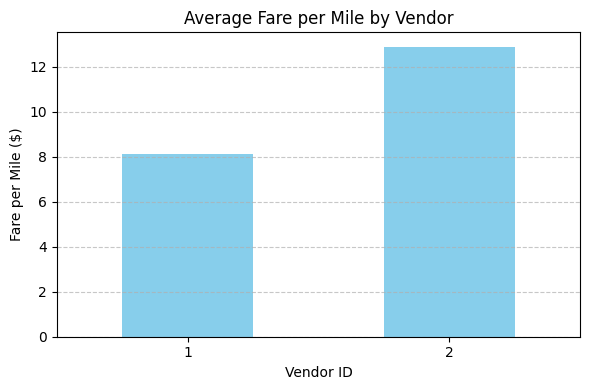

In [393]:
# Compare fare per mile for different vendors
df_vendor = df_new[df_new['trip_distance'] > 0].copy()

df_vendor['fare_per_mile'] = df_vendor['fare_amount'] / df_vendor['trip_distance']

vendor_fare_comparison = df_vendor.groupby('VendorID')['fare_per_mile'].mean().sort_values()

vendor_fare_comparison.plot(kind='bar', color='skyblue', figsize=(6, 4))
plt.title('Average Fare per Mile by Vendor')
plt.xlabel('Vendor ID')
plt.ylabel('Fare per Mile ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


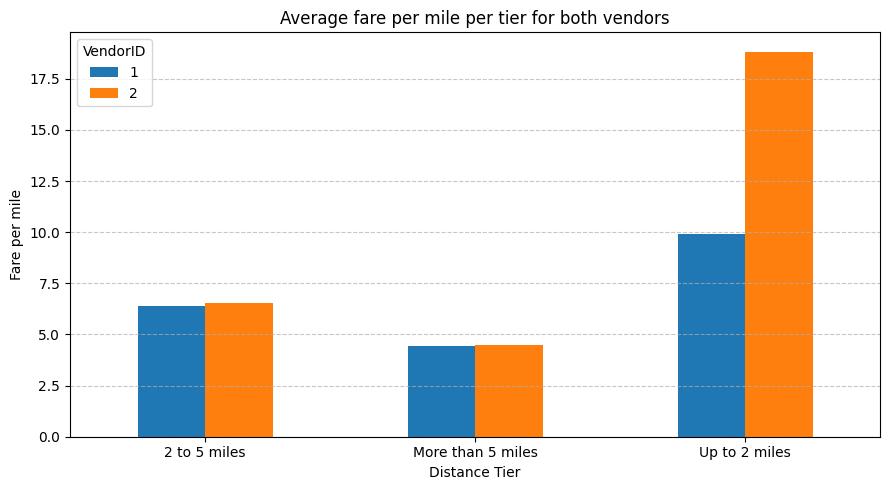

In [396]:
# Defining distance tiers
df_new['fare_per_mile'] = df_new['fare_amount'] / df_new['trip_distance']
df_new = df_new[df_new['trip_distance'] > 0]  # Avoid division by zero

tier1 = df_new[df_new['trip_distance'] <= 2].copy()
tier2 = df_new[(df_new['trip_distance'] > 2) & (df_new['trip_distance'] <= 5)].copy()
tier3 = df_new[df_new['trip_distance'] > 5].copy()

tier1['distance_tier'] = 'Up to 2 miles'
tier2['distance_tier'] = '2 to 5 miles'
tier3['distance_tier'] = 'More than 5 miles'

tiered_data = pd.concat([tier1, tier2, tier3])

avg_fare_by_tier = tiered_data.groupby(['distance_tier', 'VendorID'])['fare_per_mile'].mean().unstack()

avg_fare_by_tier.plot(kind='bar', figsize=(9, 5))
plt.title('Average fare per mile per tier for both vendors')
plt.xlabel('Distance Tier')
plt.ylabel('Fare per mile')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [397]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
df_new['tip_percentage'] = (df_new['tip_amount'] / (df_new['total_amount'] + 1e-6)) * 100  # Avoid division by zero

tips_df = df_new[['trip_distance', 'passenger_count', 'total_amount', 'tip_amount', 'pickup_hour', 'tip_percentage']].copy()

tips_df['hour'] = tips_df['pickup_hour']

tips_df['distance_category'] = pd.cut(
    tips_df['trip_distance'], [0, 2, 5, float('inf')],
    labels=['Up to 2 miles', '2 to 5 miles', 'More than 5 miles']
)

tips_df['passenger_category'] = pd.cut(
    tips_df['passenger_count'], [0, 1, 3, float('inf')],
    labels=['1 passenger', '2-3 passengers', '4+ passengers']
)

tips_df['time_category'] = pd.cut(
    tips_df['hour'], [0, 6, 12, 18, 24],
    labels=['Midnight to 6 AM', '6 AM to Noon', 'Noon to 6 PM', '6 PM to Midnight'],
    right=False
)

print("Average Tip Percentage by Distance:")
print(tips_df.groupby('distance_category')['tip_percentage'].mean())

print("\nAverage Tip Percentage by Passenger Count:")
print(tips_df.groupby('passenger_category')['tip_percentage'].mean())

print("\nAverage Tip Percentage by Time of Pickup:")
print(tips_df.groupby('time_category')['tip_percentage'].mean())

low_tip_factors = tips_df[tips_df['tip_percentage'] < 10]
print("\nMost Common Low Tip Scenarios:")
print(low_tip_factors.groupby(['distance_category', 'passenger_category', 'time_category'])
                     .size()
                     .sort_values(ascending=False)
                     .head(10))
distance_bins = [0, 1, 2, 5, 10, 20, 50]
tips_df['distance_bin'] = pd.cut(tips_df['trip_distance'], bins=distance_bins)

tip_by_distance = tips_df.groupby('distance_bin')['tip_percentage'].mean()


Average Tip Percentage by Distance:
distance_category
Up to 2 miles        12.127744
2 to 5 miles         12.313140
More than 5 miles    11.279590
Name: tip_percentage, dtype: float64

Average Tip Percentage by Passenger Count:
passenger_category
1 passenger       12.153279
2-3 passengers    11.695456
4+ passengers     11.346980
Name: tip_percentage, dtype: float64

Average Tip Percentage by Time of Pickup:
time_category
Midnight to 6 AM    11.600103
6 AM to Noon        11.922043
Noon to 6 PM        11.842507
6 PM to Midnight    12.404715
Name: tip_percentage, dtype: float64

Most Common Low Tip Scenarios:
distance_category  passenger_category  time_category   
Up to 2 miles      1 passenger         Noon to 6 PM        14755
                                       6 PM to Midnight    10723
                                       6 AM to Noon         8951
2 to 5 miles       1 passenger         Noon to 6 PM         5960
                                       6 PM to Midnight     5800
More 

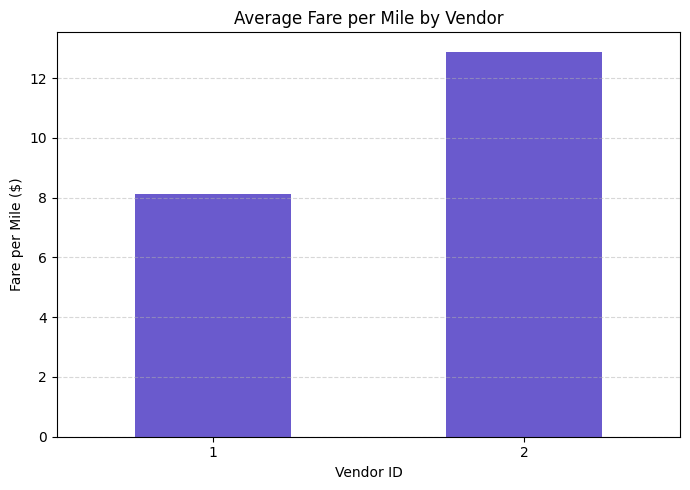

In [260]:
vendor_fare = df_new.groupby('vendorid')['fare_per_mile'].mean().sort_values()

vendor_fare.plot(kind='bar', color='slateblue', figsize=(7, 5))
plt.title('Average Fare per Mile by Vendor')
plt.xlabel('Vendor ID')
plt.ylabel('Fare per Mile ($)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [398]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

df_new['tip_percent'] = (df_new['tip_amount'] / (df_new['fare_amount'] + 1e-6)) * 100  # Avoid division by zero

low_tip = df_new[df_new['tip_percent'] < 10].copy()
high_tip = df_new[df_new['tip_percent'] > 25].copy()

comparison = pd.DataFrame({
    'Low Tip (<10%)': [
        low_tip['trip_distance'].mean(),
        low_tip['passenger_count'].mean(),
        low_tip['fare_amount'].mean(),
        low_tip['tip_amount'].mean()
    ],
    'High Tip (>25%)': [
        high_tip['trip_distance'].mean(),
        high_tip['passenger_count'].mean(),
        high_tip['fare_amount'].mean(),
        high_tip['tip_amount'].mean()
    ]
}, index=['Avg Trip Distance', 'Avg Passenger Count', 'Avg Fare Amount', 'Avg Tip Amount'])

print("Average Comparison Between Low and High Tip Trips:")
print(comparison.round(2))

Average Comparison Between Low and High Tip Trips:
                     Low Tip (<10%)  High Tip (>25%)
Avg Trip Distance              3.90             2.30
Avg Passenger Count            1.43             1.36
Avg Fare Amount               21.52            14.41
Avg Tip Amount                 0.28             4.43


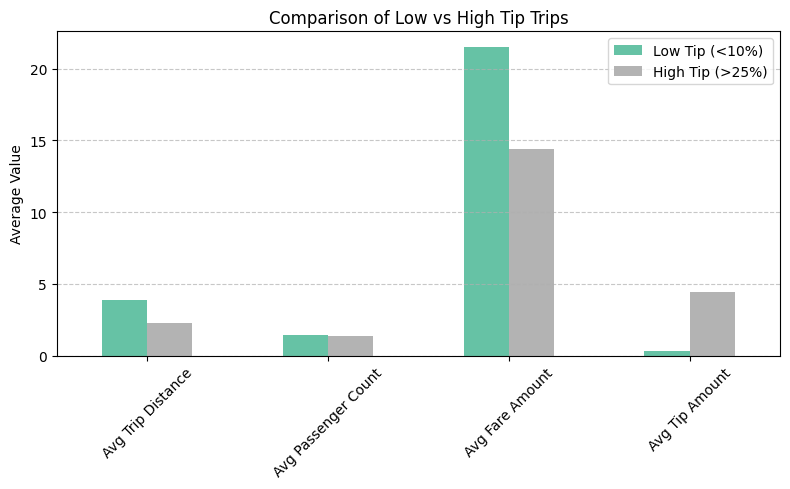

In [262]:
comparison.plot(kind='bar', figsize=(8, 5), colormap='Set2')
plt.title('Comparison of Low vs High Tip Trips')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

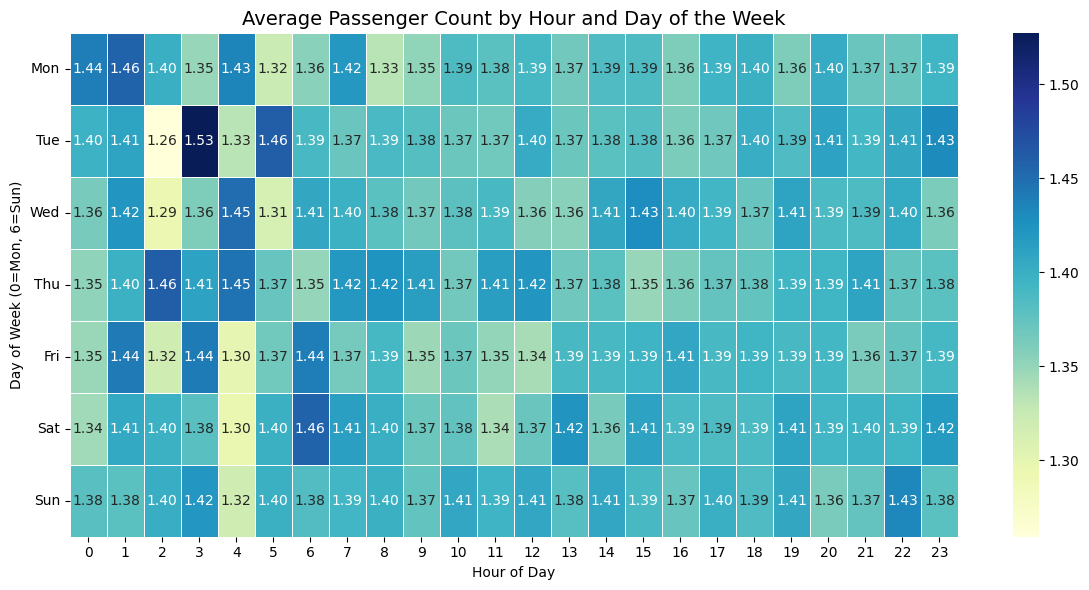

In [399]:
# See how passenger count varies across hours and days

df_new['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df_new['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek

passenger_variation = df_new.groupby(['pickup_dayofweek', 'pickup_hour'])['passenger_count'].mean().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(passenger_variation, cmap='YlGnBu', linewidths=0.5, annot=True, fmt=".2f")
plt.title('Average Passenger Count by Hour and Day of the Week', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week (0=Mon, 6=Sun)')
plt.yticks(ticks=np.arange(7) + 0.5, labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)
plt.tight_layout()
plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

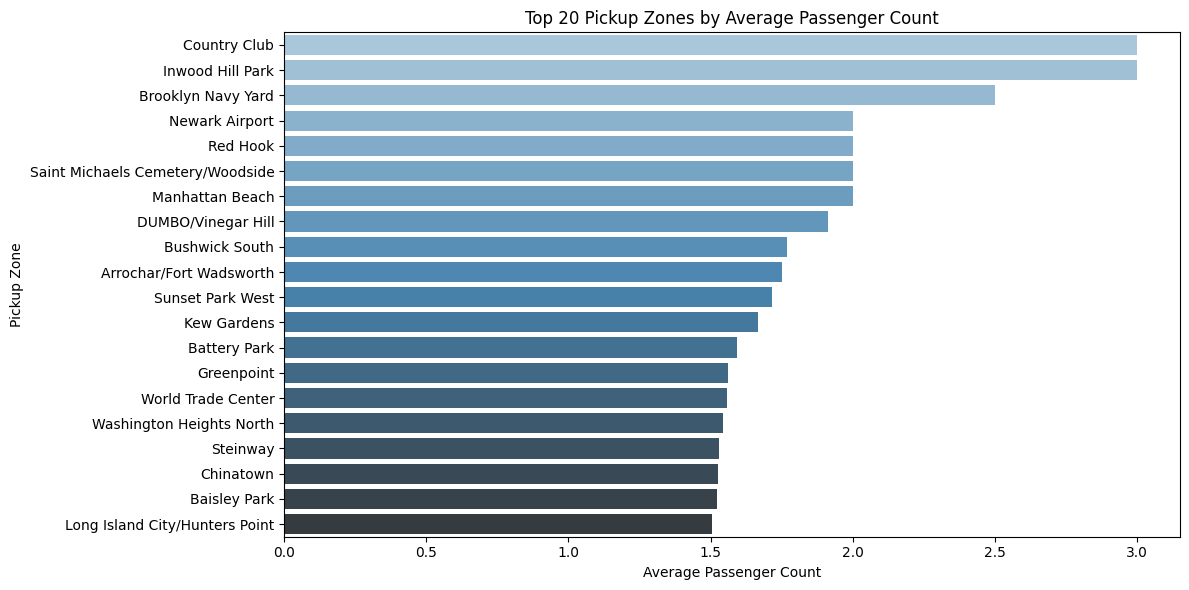

In [403]:
# How does passenger count vary across zones

zone_passenger_avg = df_new.groupby('PULocationID')['passenger_count'].mean().reset_index()

zone_passenger_avg = zone_passenger_avg.merge(zones[['LocationID', 'zone']], left_on='PULocationID', right_on='LocationID', how='left')

zone_passenger_avg = zone_passenger_avg.sort_values(by='passenger_count', ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=zone_passenger_avg, x='passenger_count', y='zone', palette='Blues_d')
plt.title('Top 20 Pickup Zones by Average Passenger Count')
plt.xlabel('Average Passenger Count')
plt.ylabel('Pickup Zone')
plt.tight_layout()
plt.show()

In [266]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

avg_passenger_by_zone = df_new.groupby('pulocationid')['passenger_count'].mean().reset_index()
avg_passenger_by_zone.rename(columns={'passenger_count': 'avg_passenger_count'}, inplace=True)
zones_with_trips = zones_with_trips.merge(avg_passenger_by_zone, left_on='LocationID', right_on='pulocationid', how='left')
zones_with_trips.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,pulocationid_x,num_trips,pulocationid_y,avg_passenger_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,29.0,1.0,2.000000
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN,NaN,NaN,NaN
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,9.0,3.0,1.000000
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,314.0,4.0,1.432343
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",5.0,4.0,5.0,1.000000


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

Frequency of Surcharge Application (%):
extra                    62.276327
mta_tax                  99.349729
tip_amount               78.050707
tolls_amount              8.044440
improvement_surcharge    99.988605
congestion_surcharge     92.919571
airport_fee_combined      8.778653
dtype: float64


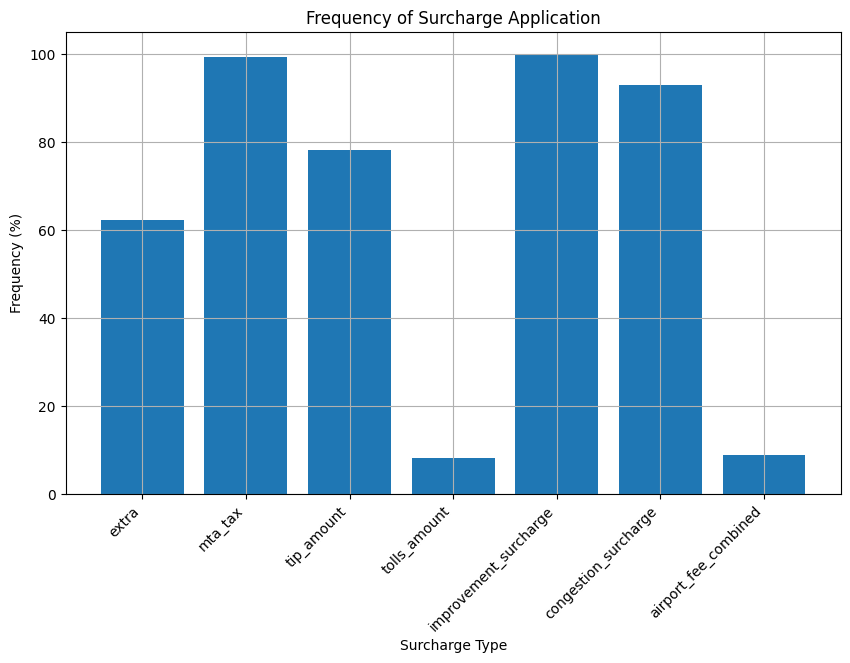

In [404]:
# How often is each surcharge applied?
surcharge_cols = ['extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee_combined']

surcharge_frequency = df_new[surcharge_cols].astype(bool).sum() / len(df_new) * 100

print("Frequency of Surcharge Application (%):")
print(surcharge_frequency)

plt.figure(figsize=(10, 6))
plt.bar(surcharge_frequency.index, surcharge_frequency.values)
plt.title('Frequency of Surcharge Application')
plt.xlabel('Surcharge Type')
plt.ylabel('Frequency (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

1. Peak Hour strategy
   
   Observation from analysis:
   - Taxi demand is heavily concentrated during specific peak hours (typically morning commute, evening rush).
   - Off-peak hours show significantly lower pickup volumes.
     
   Recommendation:
   - Increase taxi availability during top 5 busiest hours
    - By providing drivers special incentives
   - Scheduling more vehicles before pick up demand starts
3. Day-of-week dispatch optimization
   
   Observation from analysis:
   - Weekdays show consistent commute-driven demand.
   - Weekends have higher late-night and leisure-driven demand.

   Recommendation:
    - Prioritize Business hubs, corporate parks during weekdays
    - Prioritize entertainment zones, airports and nightlife areas.
      

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

1. Time-based Cab Positioning

Peak Hours (Morning & Evening):

Increase cab availability during morning peak hours (office commute) and evening peak hours (return commute).

Position more cabs near business districts, transport hubs, and residential exit zones during these times.

Off-Peak Hours (Late Night / Early Morning):

Reduce fleet concentration in low-demand zones.

Keep limited cabs near airports, railway stations, hospitals, and nightlife areas where demand still exists.

 2. Day-of-Week Strategy

Weekdays (Mon–Fri):

Focus on office-centric zones, IT parks, commercial areas, and metro stations.

Morning demand is stronger than weekends, so proactive positioning is critical.

Weekends (Sat–Sun):

Shift cabs toward entertainment zones, shopping areas, tourist spots, and leisure destinations.

Late evening and night demand is usually higher on weekends.

3. Monthly / Seasonal Adjustments

High-demand months (tourist seasons, festivals, holidays):

Increase fleet size or shift drivers to longer working windows.

Position cabs near hotels, airports, tourist attractions, and event venues.

Low-demand months:
- Reduce idle time by consolidating fleet in high-density zones.
- Schedule vehicle maintenance during these periods.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

Based on the analysis of trip distance, fare amount, time-based demand patterns, and payment behavior, the following pricing strategy adjustments are recommended to maximize revenue while remaining competitive:
1. Time based dynamic pricing with limited surge charge lower than competitors. Benefit we can obtain from this is increased revenue during high demand periods without comprimising on price sensitiving riders.
2. Since majority of trips are short trips (< 1 mile), we can propose reduced wait time incentive for drivers by assigning them multiple short trips and giving them incentives for reduced wait time
3. As there is strong correlation between trip_distance and fare_amount, we should immediately flag anomalies and try to reduce inconsistent pricing and should maintain transparent distance based pricing.
4. Payment type incentives for credit card holders. As credit card payments dominate significantly, we can introduce loyalty points and offer small cashbacks to encourage digital payment further which can improve operational efficiency and customer satisfaction
5. Certain zones and routes consistently generate high demand. So we can introduce zone based pricing premium for high pickup drop zones and keep pricing competitive in low-demand zones.
   